## Early Disease Prediction ML Model

**Introduction**

* Early and accurate disease detection is a major challenge in healthcare, especially when decisions are made using limited patient information at initial stages. Symptoms of many diseases overlap, and important factors such as age, gender, blood pressure, and cholesterol may not always be fully considered, leading to delayed or inaccurate diagnosis.

* With the growth of healthcare data and machine learning techniques, there is an opportunity to support clinical decision-making using data-driven models. These models can learn patterns from patient data to predict disease outcomes and identify important risk factors.

* This project focuses on developing a machine learning-based system that predicts disease outcomes from symptoms and health indicators while also identifying key factors influencing diagnosis.

**Background of the Study**

* Healthcare systems often rely on symptoms and basic physiological measurements to make early diagnostic decisions. However, these indicators can be ambiguous and may not clearly distinguish between different diseases.

* Delayed diagnosis can affect treatment outcomes and patient health. As healthcare datasets become more available, machine learning has emerged as a useful tool for analyzing complex relationships between symptoms, demographics, and medical indicators.

* This study uses machine learning techniques to identify patterns in patient data, determine key risk factors, and improve early disease prediction and clinical support.


**About dataset**
The dataset contains patient health information used for disease prediction analysis. It includes symptom-based features along with demographic and physiological variables such as age, gender, blood pressure, and cholesterol levels. The target variable represents the disease outcome.

This combination of clinical symptoms and patient profile data enables analysis of risk factors, identification of important patterns, and development of machine learning models for predicting disease presence and supporting early diagnosis



**Disease** – The diagnosed disease or medical condition (categorical).

**Fever** – Presence of fever in the patient (Yes/No).

**Cough** – Presence of a cough (Yes/No).

**Fatigue** – Whether the patient reports fatigue (Yes/No).

**Difficulty Breathing** – Whether the patient has trouble breathing (Yes/No).

**Age** – Patient's age in years (numeric).

**Gender** – Patient's gender (Male/Female).

**Blood Pressure** – Blood pressure level of the patient (Normal/High).

**Cholesterol Level** – Cholesterol level status (Normal/High).

**Outcome Variable** – Diagnosis result (Positive/Negative).

## Method and Approach Used

Machine learning techniques are then applied to build predictive models that support early disease detection and improve decision-making in healthcare.

In this project, the following methods will be applied.
1. Project Objective
2. Load and import datatset
3. Exploratory Data Analysis (EDA)
4. Statistical Analysis (Chi square test)
5. Data Preprocessing
6. Features Engineering
7. Splitting dataset
8. Train and Test Model
9. Build Models
10. Model Evaluation
11. Model saving and Deployment

## 1. Project Objectives

* Healthcare professionals often make early diagnostic decisions using limited patient information, which can lead to misinterpretation of symptoms and delayed treatment due to overlooked risk factors such as age, gender, blood pressure, and cholesterol.

* This project investigates whether machine learning can:

* Identify key symptoms and patient characteristics linked to disease diagnosis
Predict disease outcomes using symptoms and vital indicators
Reveal relationships between risk factors and diagnosis results
Show how demographic groups differ in symptom patterns

* **Aim** is to analyze how combinations of symptoms and patient characteristics contribute to a positive or negative diagnosis and support early disease detection. By develop machine learning models such as Logistic Regression, Decision Trees, Random Forest, and XGBoost that can learn from pattern and serve as decision support tools in clinical settings.

## 2. Load Dataset and importing libraries



**Importing necessary Libraries**

This project uses pandas and numpy for data cleaning and processing, matplotlib and seaborn for data visualization, and scikit-learn and  XGBoost for building and evaluating machine learning models.

Together, these libraries enable efficient data analysis, pattern discovery, and accurate disease prediction

In [1]:
# importing libraries for data analysis and connection to database
import pandas as pd
import numpy as np
from sqlalchemy import create_engine

# Imporring libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# imorting Libraries for data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Importing libraries for machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Importing libraries for model evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay

# Importing libraries for model selection and hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# importing libraries for saving the model
import joblib

# Importing library for Anova test and chi-square test
from scipy.stats import f_oneway, chi2_contingency

print("Libraries imported successfully")

Libraries imported successfully


**Load and connect Dataset**

The dataset was loaded from a SQL database by first establishing a connection and then running SQL queries to retrieve the required data. The dataset, which includes disease symptoms and patient profile information, was then imported into a pandas DataFrame for further analysis. This method allowed easy access to structured data and ensured smooth integration with the data analysis and machine learning processes.

In [ ]:
# connection of database

Username = 'postgres'
Password = '2002'
Host = 'localhost'
Port = '5432'
Database = 'disease_db'

# create connection
engine = create_engine(f'postgresql://{Username}:{Password}@{Host}:{Port}/{Database}')

# query 
query = "SELECT *FROM disease_prediction";

# read data into a DataFrame
df = pd.read_sql(query, engine)
print("Data loaded into DataFrame successfully")

ModuleNotFoundError: No module named 'psycopg2'

## 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) was performed to understand the structure and patterns within the dataset. The distribution of symptoms, demographic variables, and health indicators was examined to identify common trends and variations among patients. Relationships between features and disease outcomes were explored using cross-tabulations and correlation analysis.

Different type of EDA were applied  such as
- Univariate - To dsicover the distribution of symptoms, demographic variables, and health indicators was examined to identify common trends and variations among patients by using histogram,Density plot, box plot and statistical summury
- Bivariate -  Relationships between features and disease outcomes were explored using cross-tabulations and correlation analysisn such as scatter and regression plot
- Multivariate - heatmaps were used to highlight key patterns, detect outliers, and understand associations between variables

In [ ]:
# display the first 10 rows of the DataFrame
df.head(10)

,disease,fever,cough,fatigue,difficulty_breathing,age,gender,blood_pressure,cholesterol,outcome_variable
0,Influenza,Yes,No,Yes,Yes,19,Female,Low,Normal,Positive
1,Common Cold,No,Yes,Yes,No,25,Female,Normal,Normal,Negative
2,Eczema,No,Yes,Yes,No,25,Female,Normal,Normal,Negative
3,Asthma,Yes,Yes,No,Yes,25,Male,Normal,Normal,Positive
4,Asthma,Yes,Yes,No,Yes,25,Male,Normal,Normal,Positive
5,Eczema,Yes,No,No,No,25,Female,Normal,Normal,Positive
6,Influenza,Yes,Yes,Yes,Yes,25,Female,Normal,Normal,Positive
7,Influenza,Yes,Yes,Yes,Yes,25,Female,Normal,Normal,Positive
8,Hyperthyroidism,No,Yes,No,No,28,Female,Normal,Normal,Negative
9,Hyperthyroidism,No,Yes,No,No,28,Female,Normal,Normal,Negative


In [ ]:
# Shape of dataset
print("This dataset contains {} rows and {} columns.".format(df.shape[0], df.shape[1]))

This dataset contains 349 rows and 10 columns.


In [ ]:
# Info about dataset
print("Dataset information:")
df.info()

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   disease               349 non-null    str  
 1   fever                 349 non-null    str  
 2   cough                 349 non-null    str  
 3   fatigue               349 non-null    str  
 4   difficulty_breathing  349 non-null    str  
 5   age                   349 non-null    int64
 6   gender                349 non-null    str  
 7   blood_pressure        349 non-null    str  
 8   cholesterol           349 non-null    str  
 9   outcome_variable      349 non-null    str  
dtypes: int64(1), str(9)
memory usage: 27.4 KB


In [ ]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

Missing values in each column:
 disease                 0
fever                   0
cough                   0
fatigue                 0
difficulty_breathing    0
age                     0
gender                  0
blood_pressure          0
cholesterol             0
outcome_variable        0
dtype: int64


In [ ]:
# check for duoplicate rows
print("Number of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 49


**Insight**

The dataset is relatively small, containing 349 records and 10 features. There are no missing values, indicating complete data across all variables. However, 49 duplicate records were identified, suggesting that some patient entries appear more than once. These duplicates need to be handled carefully to avoid bias and ensure accurate model performance.

#### Univarite Analysis


In [ ]:
# Summary statistics of numerical columns
print("Summary statistics of numerical columns:")
print(df.describe())

Summary statistics of numerical columns:
              age
count  349.000000
mean    46.323782
std     13.085090
min     19.000000
25%     35.000000
50%     45.000000
75%     55.000000
max     90.000000


**Insight**

Since we have only one numerical feature in dataset, age distribution indicating there are different patient record depend on age group younger adult, adult and elder, also most patients fall within the 35–55 years age range, which is the dominant age group in the dataset

The median age (50%) is 45 years, which is close to the mean, suggesting a fairly balanced age distribution without extreme skewness.

Stander deviation is small indicating that moderate variation in ages.

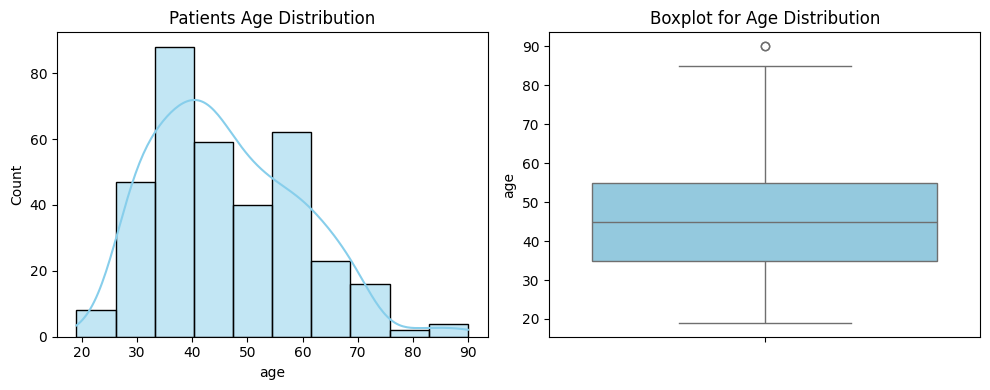

In [ ]:
# Histrogram and box plot for age distribution
fig,axes = plt.subplots(1,2, figsize = (10,4))

sns.histplot(df["age"], color="skyblue", bins = 10 , ax=axes[0],kde="True")
axes[0].set_title("Patients Age Distribution")

sns.boxplot(y= df["age"], color="skyblue", ax= axes[1])
axes[1].set_title("Boxplot for Age Distribution")

plt.tight_layout()
plt.show()

**Insight**

Age distribution is slightly normal, showing that most of the patients are middle aged, while the full range from 19 to 90 years shows that both young adults and elderly individuals are included in the dataset.

In [ ]:
# Age group distribution
age_bins = [0, 18, 35, 50, 65, np.inf]
age_labels = ['0-18', '19-35', '36-50', '51-65', '66+']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

### Bivariate Analysis

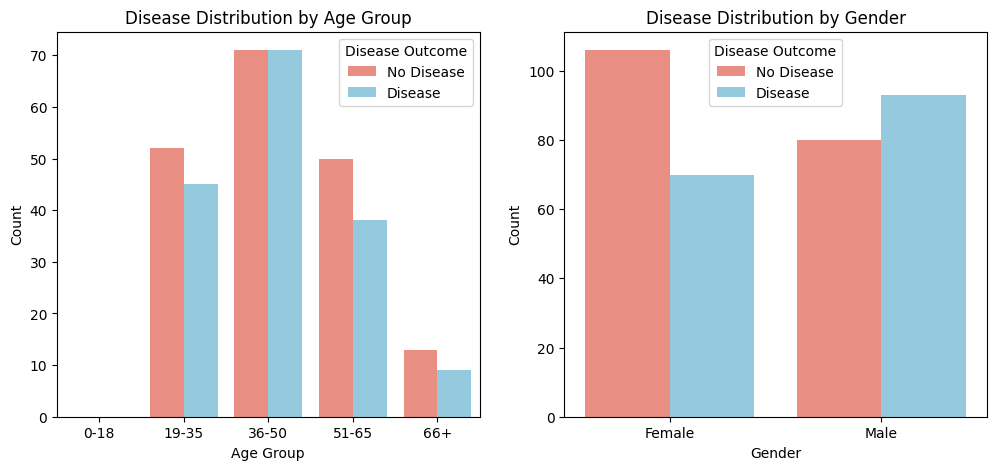

In [ ]:
# Most group affected by disease

# Define colors: [No Disease, Disease]
colors = ['lightorange', 'skyblue']  # but "lightorange" is not valid

# Correct colors:
colors = ['salmon', 'skyblue']  # light orange + skyblue

fig,axes = plt.subplots(1,2, figsize=(12,5))
sns.countplot(x='age_group', hue='outcome_variable',ax=axes[0], data=df, palette=colors)
axes[0].set_title("Disease Distribution by Age Group")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Count")
axes[0].legend(title='Disease Outcome', labels=['No Disease', 'Disease'])

sns.countplot(x='gender', hue='outcome_variable', ax=axes[1], data=df, palette=colors)
axes[1].set_title("Disease Distribution by Gender")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Count")
axes[1] .legend(title='Disease Outcome', labels=['No Disease', 'Disease'])


plt.show()

**Insight**

From the bar chart, the age group 36–50 years shows the highest number of disease cases, followed by the 19–35 years group. This indicates that middle-aged individuals are more affected compared to younger and older groups. Additionally, the distribution by gender shows that males have a higher number of disease cases than females, suggesting a possible gender-related difference in disease prevalence within the dataset.

In [ ]:
# Generate cross-tabulation tables for each symptom vs outcome
symptoms = ['fever', 'cough', 'fatigue', 'difficulty_breathing', 'blood_pressure','cholesterol']
for symptom in symptoms:
    crosstab = pd.crosstab(df[symptom], df['outcome_variable'])
    print(f"Cross-tabulation for {symptom} vs Outcome:")
    print("--"*21)
    print(crosstab)
    print("\n")


Cross-tabulation for fever vs Outcome:
------------------------------------------
outcome_variable  Negative  Positive
fever                               
No                      97        77
Yes                     66       109


Cross-tabulation for cough vs Outcome:
------------------------------------------
outcome_variable  Negative  Positive
cough                               
No                      84        98
Yes                     79        88


Cross-tabulation for fatigue vs Outcome:
------------------------------------------
outcome_variable  Negative  Positive
fatigue                             
No                      61        46
Yes                    102       140


Cross-tabulation for difficulty_breathing vs Outcome:
------------------------------------------
outcome_variable      Negative  Positive
difficulty_breathing                    
No                         129       132
Yes                         34        54


Cross-tabulation for blood_pressure vs 

**Insight**

**Indicators that show presence of disease in datasets:** Fever, Fatigue, Difficulty Breathing, High Blood Pressure, High Cholesterol.

**Indicators that show absence of disease in dataset:** Low Blood Pressure and  Low Cholesterol

**Weak predictor:** Cough (nearly balanced).

Cross-tabulation shows tendencies — some symptoms and health indicators show disease presence or absence.

In [ ]:
symptoms = ['fever', 'cough', 'fatigue', 'difficulty_breathing', 'blood_pressure','cholesterol']

results = {}

for symptom in symptoms:
    # Cross-tabulation normalized by row (percentages)
    crosstab = pd.crosstab(df[symptom], df['outcome_variable'], normalize='index') * 100
    
    # Average percentages across all values of the symptom
    results[symptom] = crosstab.mean().round(2)

# Convert to DataFrame
summary = pd.DataFrame(results).T

print("Symptoms vs Outcome (percentage distribution):")
print("--"*22)
print(summary)

Symptoms vs Outcome (percentage distribution):
--------------------------------------------
outcome_variable      Negative  Positive
fever                    46.73     53.27
cough                    46.73     53.27
fatigue                  49.58     50.42
difficulty_breathing     44.03     55.97
blood_pressure           55.98     44.02
cholesterol              53.46     46.54


**Insight**

Fever (53.27% presence) - Patients with fever are slightly more likely to have disease.

Cough (53.27% presence) - Patients with cough are slightly more likely to have disease.

Fatigue (50.42% absence) - Very close to equal proportion, indicating presence and absence of disease at sometimes.

Difficulty breathing (55.97% presence) - Strongest symptom leaning toward presence of disease.

Blood pressure (55.98% absence) - This show absence of disease.

Cholesterol (53.46% absence) - Also leans toward absence of disease.

## 4. Statistical Analysis and importance features

In this process we applied statistical technique (Anova and chi-square) to determine Correlation analysis between features and diagnosis outcome.
* Anova is for testing statistical significant between numerical features(age) and categorical targets(outcome variable).
* chi square is for testing statistical significance between categorical features(fever,cough,fatigue,	difficulty_breathing, gender,blood_pressure,cholesterol) and categorical targets(outcome variable)

* for Anova test, when Pvalue is less than 0.05 it indicates a strong statistical significance and 
when F score is greater it indicates a strong statistical significance.

* for chi square test when P value is less than 0.05 and chi square is greater, it  indicates strong statistical significance.

In [ ]:
# Anova test for numerical features
features = ['age']
anova_results = {}

for feature in features:
    groups = [df[df['outcome_variable'] == outcome][feature] for outcome in df['outcome_variable'].unique()]
    anova_results[feature] = f_oneway(*groups) 

print("ANOVA test results for numerical features:")
for feature, result in anova_results.items():
    print(f"{feature}: F-statistic = {result.statistic:.2f}, p-value = {result.pvalue:.4f}")    


ANOVA test results for numerical features:
age: F-statistic = 1.00, p-value = 0.3187


In [ ]:
#chi square for categorical features
categorical_features = ['gender', 'fever', 'cough', 'blood_pressure', 'fatigue', 'cholesterol', 'difficulty_breathing']
chi2_results = {}
for feature in categorical_features:
    contingency_table = pd.crosstab(df[feature], df['outcome_variable'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    chi2_results[feature] = (chi2, p)
print("Chi-square test results for categorical features:")
for feature, result in chi2_results.items():
    print(f"{feature}: Chi-square statistic = {result[0]:.2f}, p-value = {result[1]:.4f}")       


Chi-square test results for categorical features:
gender: Chi-square statistic = 6.30, p-value = 0.0120
fever: Chi-square statistic = 10.69, p-value = 0.0011
cough: Chi-square statistic = 0.01, p-value = 0.9140
blood_pressure: Chi-square statistic = 14.56, p-value = 0.0007
fatigue: Chi-square statistic = 6.00, p-value = 0.0143
cholesterol: Chi-square statistic = 33.96, p-value = 0.0000
difficulty_breathing: Chi-square statistic = 2.66, p-value = 0.1029


**Insight** 

Gender, fever, blood_presure, fatigue, this features shows a very high statistical significant to outcome variables. (positive and negative) indicating possibility of diseases

but cholesterol is a very strong indicator in disease prediction

## 5. Data Preprocessing

In this step we're going to do data cleaning, filling the missing value, handling duplicate and outliers.
 aim is to determine the quality of the data.
 in this process we're going to standardize our features to avoid domination,and also perform encoding to convert categorical to numerical value.


In [ ]:
# handling duplicate 
df_clean = df.copy()
df_clean=df_clean.drop_duplicates()

**Insight**

Now duplicate is already removed and another approach such as encoding,nomalization and class imbalance will be conducted in spliting process before modeling

## 6. Feature Engineering

In this process another column "age_group" was added during visualizie the outcome variable vs age group


## 7. Splitting dataset 

* in this step we're going to split our dataset in features and targets.

In [ ]:
df_clean.head()

,disease,fever,cough,fatigue,difficulty_breathing,age,gender,blood_pressure,cholesterol,outcome_variable,age_group
0,Influenza,Yes,No,Yes,Yes,19,Female,Low,Normal,Positive,19-35
1,Common Cold,No,Yes,Yes,No,25,Female,Normal,Normal,Negative,19-35
2,Eczema,No,Yes,Yes,No,25,Female,Normal,Normal,Negative,19-35
3,Asthma,Yes,Yes,No,Yes,25,Male,Normal,Normal,Positive,19-35
5,Eczema,Yes,No,No,No,25,Female,Normal,Normal,Positive,19-35


In [ ]:

# Features and targets
X = df_clean.drop(['outcome_variable', 'disease','age_group'], axis=1)
y_outcome = df_clean['outcome_variable']
y_disease = df_clean['disease']

# Encode Binary Features
binary_cols = [
    'gender',
    'fever',
    'fatigue',
    'difficulty_breathing',
    'cough'
]

label_encoders = {}

for col in binary_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# One-Hot Encode Nominal Features
nominal_cols = ['blood_pressure', 'cholesterol']

one_hot_encoder = OneHotEncoder(
    drop='first',
    sparse_output=False,
    dtype=int
)

encoded_features = one_hot_encoder.fit_transform(X[nominal_cols])

encoded_df = pd.DataFrame(
    encoded_features,
    columns=one_hot_encoder.get_feature_names_out(nominal_cols),
    index=X.index
)

X = X.drop(columns=nominal_cols)
X = pd.concat([X, encoded_df], axis=1)

# Encode Targets
outcome_encoder = LabelEncoder()
y_outcome_encoded = outcome_encoder.fit_transform(y_outcome)

In [ ]:
X.head()

,fever,cough,fatigue,difficulty_breathing,age,gender,blood_pressure_Low,blood_pressure_Normal,cholesterol_Low,cholesterol_Normal
0,1,0,1,1,19,0,1,0,0,1
1,0,1,1,0,25,0,0,1,0,1
2,0,1,1,0,25,0,0,1,0,1
3,1,1,0,1,25,1,0,1,0,1
5,1,0,0,0,25,0,0,1,0,1


In [ ]:
y_outcome_encoded[:10]

array([1, 0, 0, 1, 1, 1, 0, 1, 0, 0])

In [ ]:
y_disease[:2]

0      Influenza
1    Common Cold
Name: disease, dtype: str

## 8. Train and test Model

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_outcome_train, y_outcome_test = train_test_split(
    X,
    y_outcome_encoded,
    test_size=0.2,
    random_state=42
)

## 9. Build Model and Evaluation

##### Randon forest Model

In [ ]:
# Apply random forest model for outcome prediction
Ran_model = RandomForestClassifier(random_state=42)
Ran_model.fit(X_train, y_outcome_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
# evaluate the model
y_pred = Ran_model.predict(X_test)
print("Outcome Accuracy:", accuracy_score(y_outcome_test, y_pred))
print("Classification report:\n", classification_report(y_outcome_test, y_pred))

Outcome Accuracy: 0.6333333333333333
Classification report:
               precision    recall  f1-score   support

           0       0.60      0.56      0.58        27
           1       0.66      0.70      0.68        33

    accuracy                           0.63        60
   macro avg       0.63      0.63      0.63        60
weighted avg       0.63      0.63      0.63        60



In [ ]:
# disease prediction and evaluation
positive_mask = y_outcome == 'Positive'

X_positive = X[positive_mask]
y_positive_disease = y_disease[positive_mask]

disease_encoder = LabelEncoder()
y_positive_encoded = disease_encoder.fit_transform(y_positive_disease)

disease_Rmodel = RandomForestClassifier(random_state=42)

disease_Rmodel.fit(X_positive, y_positive_encoded)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
# disease prediction and evaluation
y_pred_dis = disease_Rmodel.predict(X_positive)
print("Disease Accuracy:", accuracy_score(y_positive_encoded, y_pred_dis))

Disease Accuracy: 0.8089171974522293


#### KNN Model

In [ ]:
## KNN model
KNN_model = KNeighborsClassifier()
KNN_model.fit(X_train, y_outcome_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [ ]:
# evaluate the model
y_pred = KNN_model.predict(X_test)
print("Outcome Accuracy:", accuracy_score(y_outcome_test, y_pred))
print("classification report:\n", classification_report(y_outcome_test, y_pred))

Outcome Accuracy: 0.6666666666666666
classification report:
               precision    recall  f1-score   support

           0       0.65      0.56      0.60        27
           1       0.68      0.76      0.71        33

    accuracy                           0.67        60
   macro avg       0.66      0.66      0.66        60
weighted avg       0.67      0.67      0.66        60



In [ ]:
positive_mask = y_outcome == 'Positive'

X_positive = X[positive_mask]
y_positive_disease = y_disease[positive_mask]

disease_encoder = LabelEncoder()
y_positive_encoded = disease_encoder.fit_transform(y_positive_disease)

disease_Kmodel = KNeighborsClassifier(n_neighbors=5)

disease_Kmodel.fit(X_positive, y_positive_encoded)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [ ]:
# disease prediction and evaluation
y_pred_dis = disease_Kmodel.predict(X_positive)
print("Disease Accuracy:", accuracy_score(y_positive_encoded, y_pred_dis))

Disease Accuracy: 0.24203821656050956


#### XGBoost Model

In [ ]:
## XGBoost model
XGB_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
XGB_model.fit(X_train, y_outcome_train)

c:\Users\hp\OneDrive\Desktop\disease prediction\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:06:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [ ]:
# evaluate the model
y_pred = XGB_model.predict(X_test)
print("Outcome Accuracy:", accuracy_score(y_outcome_test, y_pred))
print("classification report:\n", classification_report(y_outcome_test, y_pred))

Outcome Accuracy: 0.7333333333333333
classification report:
               precision    recall  f1-score   support

           0       0.74      0.63      0.68        27
           1       0.73      0.82      0.77        33

    accuracy                           0.73        60
   macro avg       0.73      0.72      0.73        60
weighted avg       0.73      0.73      0.73        60



In [ ]:
positive_mask = y_outcome == 'Positive'

X_positive = X[positive_mask]
y_positive_disease = y_disease[positive_mask]

disease_encoder = LabelEncoder()
y_positive_encoded = disease_encoder.fit_transform(y_positive_disease)

disease_Xmodel = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

disease_Xmodel.fit(X_positive, y_positive_encoded)

c:\Users\hp\OneDrive\Desktop\disease prediction\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:06:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [ ]:
# disease prediction and evaluation
y_pred_dis = disease_Xmodel.predict(X_positive)
print("Disease Accuracy:", accuracy_score(y_positive_encoded, y_pred_dis))

Disease Accuracy: 0.5605095541401274


#### Important features in selection model

In [ ]:

# Get importance scores
importance_scores = Ran_model.feature_importances_

# Create ranking table
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance_scores
})

# Sort descending
feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance_df)

NameError: name 'Ran_model' is not defined

In [ ]:
# define function for prediction
def predict_patient(patient_data):
    patient = pd.DataFrame([patient_data])

    for col in binary_cols:
        patient[col] = label_encoders[col].transform(patient[col])

    encoded = one_hot_encoder.transform(patient[nominal_cols])

    encoded_df = pd.DataFrame(
        encoded,
        columns=one_hot_encoder.get_feature_names_out(nominal_cols)
    )

    patient = patient.drop(columns=nominal_cols)
    patient = pd.concat([patient, encoded_df], axis=1)

    patient = patient.reindex(columns=X.columns, fill_value=0)

    outcome_pred = Ran_model.predict(patient)[0]
    outcome_label = outcome_encoder.inverse_transform([outcome_pred])[0]

    if outcome_label == 'Negative':
        print("Prediction Result: Negative")
        print("No disease detected.")
        return

    disease_pred = disease_Rmodel.predict(patient)[0]
    disease_label = disease_encoder.inverse_transform([disease_pred])[0]

    print("Prediction Result: Positive")
    print("Predicted Disease:", disease_label)

In [ ]:
patient_data = {
    'age': int(input("Enter Age: ")),
    'gender': input("Enter Gender (male/female): ").strip().title(),
    'fever': input("Enter Fever (yes/no): ").strip().title(),
    'cough': input("Enter Cough (yes/no): ").strip().title(),
    'fatigue': input("Enter Fatigue (yes/no): ").strip().title(),
    'difficulty_breathing': input("Enter Difficulty Breathing (yes/no): ").strip().title(),
    'blood_pressure': input("Enter Blood Pressure (low/normal/high): ").strip().title(),
    'cholesterol': input("Enter Cholesterol (low/normal/high): ").strip().title()
}

predict_patient(patient_data)

NameError: name 'binary_cols' is not defined

## 10. Model Saving

In [ ]:

# Save outcome model
joblib.dump(Ran_model, "outcome_model.pkl")

# Save disease model
joblib.dump(disease_Rmodel, "disease_model.pkl")

# Save encoders
joblib.dump(label_encoders, "label_encoders.pkl")
joblib.dump(one_hot_encoder, "one_hot_encoder.pkl")

# Save target encoders
joblib.dump(outcome_encoder, "outcome_encoder.pkl")
joblib.dump(disease_encoder, "disease_encoder.pkl")

# Save feature order
joblib.dump(X.columns, "feature_columns.pkl")

['feature_columns.pkl']

outcome_model = joblib.load("Ran_model.pkl")
disease_model = joblib.load("disease_Rmodel.pkl")

label_encoders = joblib.load("label_encoders.pkl")
one_hot_encoder = joblib.load("one_hot_encoder.pkl")

outcome_encoder = joblib.load("outcome_encoder.pkl")
disease_encoder = joblib.load("disease_encoder.pkl")

feature_columns = joblib.load("feature_columns.pkl")